## Import Libraries

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', './'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.data_loader import load_datasets, get_dataloaders
from src.data.preprocessing import get_transforms
from src.models.cnn_models import VanillaCNN
from src.training.trainer import ModelTrainer
from src.utils.config import load_config
from src.utils.helpers import FASHION_MNIST_CLASSES, get_timestamp_str
from src.evaluation.evaluator import ModelEvaluator, save_metrics
from src.evaluation.visualization import plot_confusion_matrix
print("Libraries and Custom Modules Loaded.")

Libraries and Custom Modules Loaded.


## Load Configuration

In [2]:
# Point to config.yaml
config_path = '../configs/config.yaml'
config = load_config(config_path)

# Load configuration from config.yaml
data_config = config['data']
training_config = config['training']
model_config = config['model']
paths_config = config['paths']

# Device Configuration
device_str = training_config['device']
if device_str == "cuda" and torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using Device: {device}")

# Figures Directory for Saving Plots
os.makedirs(paths_config['figures_save_dir'], exist_ok=True)

Using Device: cpu


## Data Loading and Preparation

In [3]:
# Default Transforms
transform = get_transforms()

train_dataset, test_dataset = load_datasets(raw_data_path=data_config['raw_data_path'], transforms=transform)
      
train_loader, test_loader = get_dataloaders(train_dataset, test_dataset, batch_size=training_config['batch_size'],
                                            num_workers=training_config['num_workers'], 
                                            pin_memory=training_config['pin_memory'])

print(f"Train DataLoader Batches: {len(train_loader)}")
print(f"Test DataLoader Batches: {len(test_loader)}")
print("===== Datasets Loaded and DataLoaders Created =====")

Fashion MNIST datasets successfully loaded.  Train Samples: 60000 	 Test Samples: 10000
DataLoaders created with batch size: 64
Train DataLoader Batches: 938
Test DataLoader Batches: 157
===== Datasets Loaded and DataLoaders Created =====


## Model Initialization

In [5]:
# Instatiate VanillaCNN
model = VanillaCNN(input_dim=tuple(data_config['input_shape']), num_classes=data_config['num_classes'])

# Move Model to Device
model.to(device)
print(model)
print("===== Initialize VanillaCNN model =====")

VanillaCNN(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)
===== Initialize VanillaCNN model =====


## Loss Function and Optimizer

In [6]:
# Get Loss Function
if training_config['loss_function'] == "CrossEntropyLoss":
    criterion = nn.CrossEntropyLoss()
else:
    raise ValueError(f"Unknown Loss Function: {training_config['loss_function']}")

# Get Optimizer
if training_config['optimizer'] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=training_config['learning_rate'])
elif training_config['optimizer'] == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=training_config['learning_rate'])
else:
    raise ValueError(f"Unknown Optimizer: {training_config['optimizer']}")

print(f"Criterion: {criterion}")
print(f"Optimizer: {optimizer}")
print("===== Loss Function and Optimizer Initialized =====")

Criterion: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
===== Loss Function and Optimizer Initialized =====


## Training Loop and History Tracking

In [8]:
# Initialize Trainer
trainer = ModelTrainer(model, device)

# Directories for storing training history
history = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(1, 1 + training_config['epochs']):
    print(f"\nEpoch {epoch} of {training_config['epochs']}")

    # Train the model
    train_loss, train_accuracy = trainer.train_mode(train_loader, optimizer, criterion)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    print(f"Train Loss: {train_loss:.4f} \t Train Accuracy: {train_accuracy:.4f}")

    # Validate the model
    val_loss, val_accuracy = trainer.validate_mode(test_loader, criterion)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    print(f"Validation Loss: {val_loss:.4f} \t Validation Accuracy: {val_accuracy:.4f}")

print("===== Training Complete =====")


Epoch 1 of 10


Training:   0%|          | 0/938 [00:00<?, ?it/s]C:\Users\radix\anaconda3\envs\py311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 938/938 [00:15<00:00, 62.13it/s]


Train Loss: 0.4332 	 Train Accuracy: 0.8443


Validation: 100%|██████████| 157/157 [00:05<00:00, 26.94it/s]


Validation Loss: 0.3520 	 Validation Accuracy: 0.8715

Epoch 2 of 10


...

Validation Loss: 0.2587 	 Validation Accuracy: 0.9203

Epoch 10 of 10


Training: 100%|██████████| 938/938 [00:15<00:00, 60.80it/s]


Train Loss: 0.0852 	 Train Accuracy: 0.9674


Validation: 100%|██████████| 157/157 [00:05<00:00, 26.44it/s]

Validation Loss: 0.2787 	 Validation Accuracy: 0.9208
===== Training Complete =====


## Plotting Training History

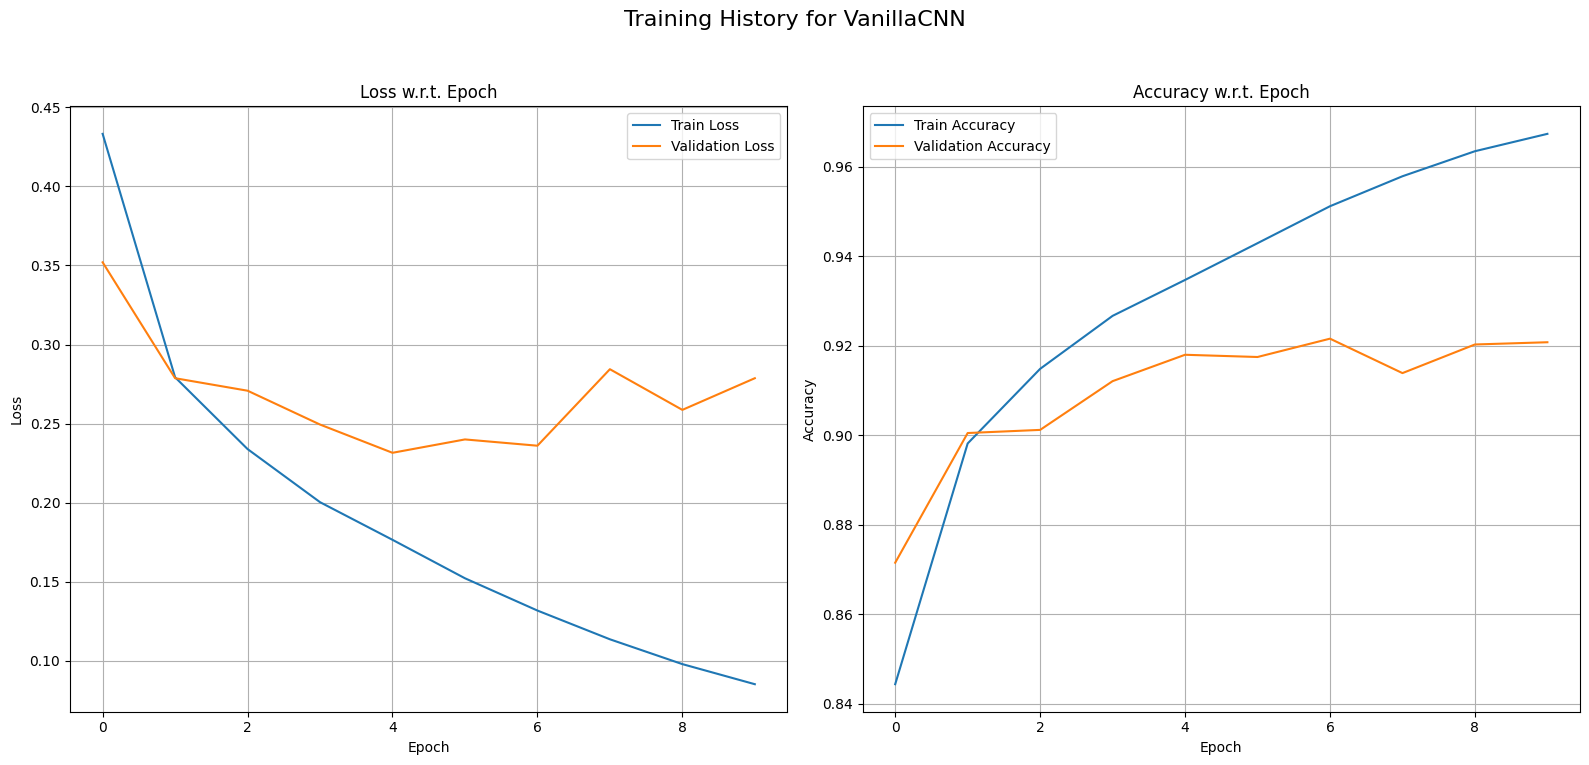

Training History Plot saved to: results/figures/baseline_model_training_history.png


In [12]:
plt.figure(figsize=(16,8))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss w.r.t. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(history['train_accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy w.r.t. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle(f"Training History for {model_config['name']}", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the plots
history_plot_path = os.path.join(paths_config['figures_save_dir'], 'baseline_model_training_history.png')
plt.savefig(history_plot_path)
plt.show()
print(f"Training History Plot saved to: {history_plot_path}")

## Get Metrics and Plot Confusion Matrix

In [17]:
# Initialize evaluator
evaluator = ModelEvaluator(model, device)

# Get predictions and true labels
true_labels, predicted_labels = evaluator.get_labels(test_loader)

# Calculate metrics
metrics = evaluator.evaluate_model_performance(true_labels, predicted_labels, FASHION_MNIST_CLASSES)

print(f"Test Accuracy: {metrics['overall_accuracy']:.4f}")
print(f"\nClassification Report:\n")
for class_name, class_metrics in metrics['classification_report'].items():
    if isinstance(class_metrics, dict):
        print(f" {class_name}: Precision={class_metrics['precision']:.2f}, "
              f"Recall={class_metrics['recall']:.2f}, F1-Score={class_metrics['f1-score']:.2f}, "
              f"Support={class_metrics['support']}")
    else:
        print(f" {class_name}: {class_metrics:.2f}" if isinstance(class_metrics, float)
              else f" {class_name}: {class_metrics}")

# Save metrics to a JSON
timestamp = get_timestamp_str()
metrics_filename = f"{paths_config['evaluation_metrics_filename_prefix']}baseline_{timestamp}.json"
metrics_save_path = os.path.join(paths_config['metrics_save_dir'], metrics_filename)
save_metrics(metrics, metrics_save_path)

# Plot Confusion Matrix
conf_matrix = metrics['confusion_matrix']
conf_matrix_filename = f"{paths_config['confusion_matrix_filename_prefix']}baseline_{timestamp}.png"
conf_matrix_save_path = os.path.join(paths_config['figures_save_dir'], conf_matrix_filename)
plot_confusion_matrix(np.array(conf_matrix), FASHION_MNIST_CLASSES, conf_matrix_save_path, normalize=True,
                      title=f'Baseline Model Confusion Matrix (Accuracy: {metrics["overall_accuracy"]:.4f})')
plt.show()
print(f"Confusion Matrix Plot saved to: {conf_matrix_save_path}")

C:\Users\radix\anaconda3\envs\py311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test Accuracy: 0.9208

Classification Report:

 T-Shirt/Top: Precision=0.90, Recall=0.83, F1-Score=0.86, Support=1000.0
 Trouser: Precision=1.00, Recall=0.98, F1-Score=0.99, Support=1000.0
 Pullover: Precision=0.86, Recall=0.91, F1-Score=0.88, Support=1000.0
 Dress: Precision=0.92, Recall=0.93, F1-Score=0.92, Support=1000.0
 Coat: Precision=0.91, Recall=0.86, F1-Score=0.88, Support=1000.0
 Sandal: Precision=0.98, Recall=0.99, F1-Score=0.99, Support=1000.0
 Shirt: Precision=0.74, Recall=0.80, F1-Score=0.77, Support=1000.0
 Sneaker: Precision=0.98, Recall=0.95, F1-Score=0.97, Support=1000.0
 Bag: Precision=0.99, Recall=0.99, F1-Score=0.99, Support=1000.0
 Ankle Boot: Precision=0.96, Recall=0.98, F1-Score=0.97, Support=1000.0
 accuracy: 0.92
 macro avg: Precision=0.92, Recall=0.92, F1-Score=0.92, Support=10000.0
 weighted avg: Precision=0.92, Recall=0.92, F1-Score=0.92, Support=10000.0
Metrics saved to: results/metrics/evaluation_metrics_baseline_20250807_005000.json
Normalized confusion 

## Observations

In [19]:
print("===== Observations from Baseline Model Training =====")
print("1. Initial Performance: The VanillaCNN model achieved an accuracy of ~92% on the test set.")
print("\n2. Learning Curve: The loss decreased as the accuracy increased over epochs, indicating the model is learning.")
print("\n3. Overfitting: The validation loss starts to increase while the training loss continues to decrease significantly.  This suggests overfitting.")

===== Observations from Baseline Model Training =====
1. Initial Performance: The VanillaCNN model achieved an accuracy of ~92% on the test set.

2. Learning Curve: The loss decreased as the accuracy increased over epochs, indicating the model is learning.

3. Overfitting: The validation loss starts to increase while the training loss continues to decrease significantly.  This suggests overfitting.
